# Student Marks Analysis

In this project I am analyzing a student marksheet dataset.
The dataset has marks of 250 students in 4 subjects - Science, English, History and Maths.

I will try to find things like who are the top students, which section performed better,
pass/fail count, grade distribution etc.

Dataset file: marksheet.csv

## Importing the required libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Loading the dataset

In [29]:
df = pd.read_csv('C:\\Users\\MUAWIYAH\\Downloads\\marksheet.csv')
df.head()

,id,Name,Gender,Age,Section,Science,English,History,Maths
0,1,Bronnie,Female,13,C,21,81,62,49
1,2,Lemmie,Male,15,B,29,41,17,40
2,3,Danya,Female,14,C,12,87,16,96
3,4,Denna,Female,14,B,15,53,82,33
4,5,Jocelin,Male,14,A,43,6,3,21


In [30]:
# checking the shape of the dataset
print('Rows and Columns:', df.shape)

Rows and Columns: (250, 9)


In [31]:
# checking data types and if there are any null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       250 non-null    int64 
 1   Name     250 non-null    object
 2   Gender   250 non-null    object
 3   Age      250 non-null    int64 
 4   Section  250 non-null    object
 5   Science  250 non-null    int64 
 6   English  250 non-null    int64 
 7   History  250 non-null    int64 
 8   Maths    250 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 17.7+ KB


In [32]:
df.isnull().sum()

id         0
Name       0
Gender     0
Age        0
Section    0
Science    0
English    0
History    0
Maths      0
dtype: int64

In [33]:
# no null values, good
# basic stats
df.describe()

,id,Age,Science,English,History,Maths
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,125.500000,14.020000,51.440000,47.980000,52.272000,53.016000
std,72.312977,0.823598,29.314497,29.949013,26.868526,27.386416
min,1.000000,13.000000,1.000000,1.000000,1.000000,1.000000
25%,63.250000,13.000000,25.250000,20.250000,31.000000,30.000000
50%,125.500000,14.000000,53.000000,47.500000,53.000000,52.500000
75%,187.750000,15.000000,78.000000,74.000000,76.000000,76.000000
max,250.000000,15.000000,100.000000,100.000000,100.000000,100.000000


## Adding new columns

I will add Total marks, Percentage, Grade and Pass/Fail columns.
Also adding a column for which subject each student scored best in.

In [34]:
subjects = ['Science', 'English', 'History', 'Maths']

# total marks out of 400
df['Total'] = df['Science'] + df['English'] + df['History'] + df['Maths']

In [35]:
# calculating percentage
df['Percentage'] = (df['Total'] / 400) * 100
df['Percentage'] = df['Percentage'].round(2)
df[['Name', 'Total', 'Percentage']].head()

,Name,Total,Percentage
0,Bronnie,213,53.25
1,Lemmie,127,31.75
2,Danya,211,52.75
3,Denna,183,45.75
4,Jocelin,73,18.25


In [36]:
# grade function - using if else conditions
def get_grade(p):
    if p >= 90:
        return 'A+'
    elif p >= 75:
        return 'A'
    elif p >= 60:
        return 'B'
    elif p >= 45:
        return 'C'
    elif p >= 33:
        return 'D'
    else:
        return 'F'

df['Grade'] = df['Percentage'].apply(get_grade)

In [37]:
# pass or fail - a student fails if they score below 33 in any one subject
def check_result(row):
    for sub in subjects:
        if row[sub] < 33:
            return 'FAIL'
    return 'PASS'

df['Result'] = df.apply(check_result, axis=1)

In [38]:
# which subject did each student score highest in
df['Best_Subject'] = df[subjects].idxmax(axis=1)

df[['Name', 'Total', 'Percentage', 'Grade', 'Result', 'Best_Subject']].head(10)

,Name,Total,Percentage,Grade,Result,Best_Subject
0,Bronnie,213,53.25,C,FAIL,English
1,Lemmie,127,31.75,F,FAIL,English
2,Danya,211,52.75,C,FAIL,Maths
3,Denna,183,45.75,C,FAIL,History
4,Jocelin,73,18.25,F,FAIL,Science
5,Malissa,310,77.50,A,PASS,Science
6,Ichabod,226,56.50,C,PASS,English
7,Beverlie,197,49.25,C,FAIL,Maths
8,Corrine,126,31.50,F,FAIL,Maths
9,Tate,124,31.00,F,FAIL,History


## Analysis

In [39]:
# overall pass fail count
print(df['Result'].value_counts())
print()
total_students = len(df)
passed = (df['Result'] == 'PASS').sum()
failed = (df['Result'] == 'FAIL').sum()
print(f'Pass percentage: {passed/total_students*100:.1f}%')
print(f'Fail percentage: {failed/total_students*100:.1f}%')

Result
FAIL    188
PASS     62
Name: count, dtype: int64

Pass percentage: 24.8%
Fail percentage: 75.2%


In [40]:
# top 5 students by percentage
print('Top 5 students:')
top5 = df.nlargest(5, 'Percentage')[['Name', 'Section', 'Total', 'Percentage', 'Grade']]
top5 = top5.reset_index(drop=True)
top5.index = top5.index + 1
print(top5)

Top 5 students:
       Name Section  Total  Percentage Grade
1      Dunn       C    361       90.25    A+
2  Patrizia       A    356       89.00     A
3       Nil       A    347       86.75     A
4     Daffi       A    341       85.25     A
5    Ruddie       B    333       83.25     A


In [41]:
# bottom 5 students
print('Bottom 5 students:')
bottom5 = df.nsmallest(5, 'Percentage')[['Name', 'Section', 'Total', 'Percentage', 'Grade']]
bottom5 = bottom5.reset_index(drop=True)
bottom5.index = bottom5.index + 1
print(bottom5)

Bottom 5 students:
       Name Section  Total  Percentage Grade
1  Ginnifer       C     57       14.25     F
2    Ashlan       B     67       16.75     F
3     Blake       B     70       17.50     F
4   Jocelin       A     73       18.25     F
5    Berget       C     73       18.25     F


In [42]:
# average marks per subject
print('Average marks in each subject:')
print(df[subjects].mean().round(2))

Average marks in each subject:
Science    51.44
English    47.98
History    52.27
Maths      53.02
dtype: float64


In [43]:
# grade distribution
print('Grade wise count:')
grade_order = ['A+', 'A', 'B', 'C', 'D', 'F']
grade_counts = df['Grade'].value_counts().reindex(grade_order).fillna(0).astype(int)
print(grade_counts)

Grade wise count:
Grade
A+     1
A     14
B     58
C     95
D     53
F     29
Name: count, dtype: int64


In [44]:
# section wise analysis
print('Average percentage by section:')
section_avg = df.groupby('Section')['Percentage'].mean().round(2)
print(section_avg)
print()
print('Pass count by section:')
section_pass = df.groupby('Section')['Result'].apply(lambda x: (x=='PASS').sum())
section_total = df.groupby('Section')['Result'].count()
for sec in section_pass.index:
    print(f'Section {sec}: {section_pass[sec]}/{section_total[sec]} passed')

Average percentage by section:
Section
A    52.06
B    52.49
C    49.29
Name: Percentage, dtype: float64

Pass count by section:
Section A: 19/79 passed
Section B: 24/79 passed
Section C: 19/92 passed


In [45]:
# gender wise comparison
print('Average percentage - Gender wise:')
print(df.groupby('Gender')['Percentage'].mean().round(2))
print()
print('Pass rate - Gender wise:')
for g in df['Gender'].unique():
    temp = df[df['Gender'] == g]
    p = (temp['Result'] == 'PASS').sum()
    print(f'{g}: {p}/{len(temp)} passed ({p/len(temp)*100:.1f}%)')

Average percentage - Gender wise:
Gender
Female    50.65
Male      51.64
Name: Percentage, dtype: float64

Pass rate - Gender wise:
Female: 28/118 passed (23.7%)
Male: 34/132 passed (25.8%)


## Visualizations

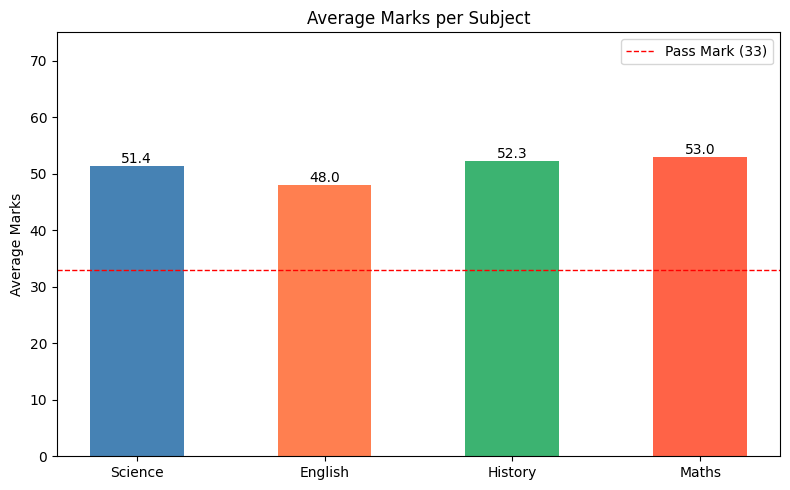

In [46]:
# bar chart - average marks per subject
sub_avg = df[subjects].mean().round(2)

plt.figure(figsize=(8, 5))
bars = plt.bar(sub_avg.index, sub_avg.values, color=['steelblue', 'coral', 'mediumseagreen', 'tomato'], width=0.5)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(round(bar.get_height(), 1)), ha='center', fontsize=10)

plt.axhline(y=33, color='red', linestyle='--', linewidth=1, label='Pass Mark (33)')
plt.title('Average Marks per Subject')
plt.ylabel('Average Marks')
plt.ylim(0, 75)
plt.legend()
plt.tight_layout()
plt.savefig('chart1_subject_avg.png', dpi=120)
plt.show()

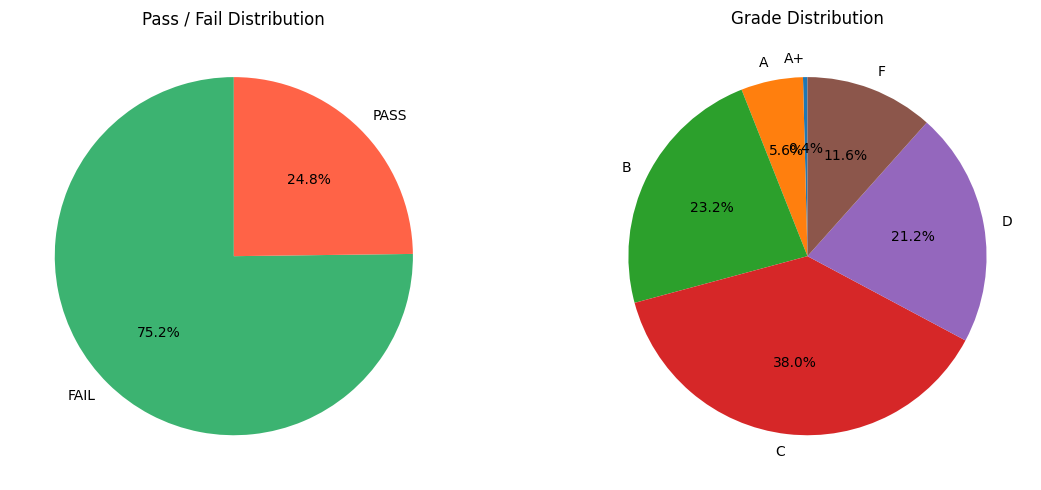

In [47]:
# pie chart for pass fail and grade distribution side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

result_counts = df['Result'].value_counts()
axes[0].pie(result_counts, labels=result_counts.index, autopct='%1.1f%%',
            colors=['mediumseagreen', 'tomato'], startangle=90)
axes[0].set_title('Pass / Fail Distribution')

gc = grade_counts[grade_counts > 0]
axes[1].pie(gc, labels=gc.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Grade Distribution')

plt.tight_layout()
plt.savefig('chart2_pie.png', dpi=120)
plt.show()

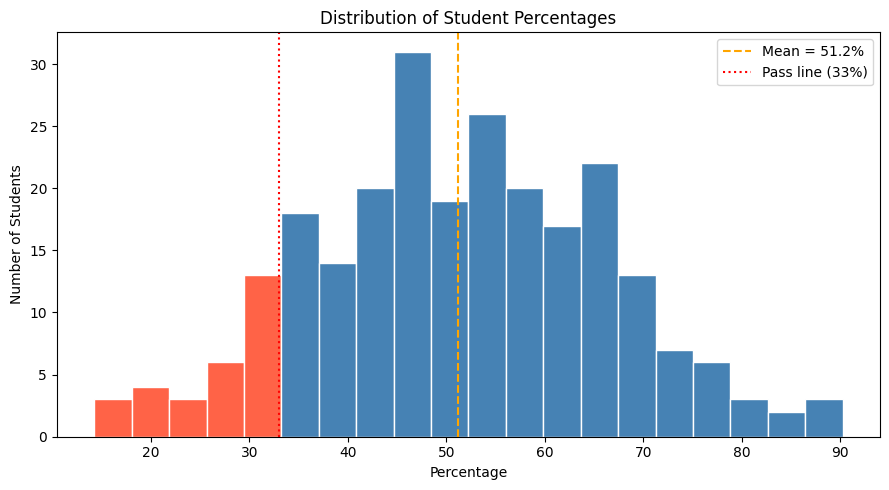

In [48]:
# histogram for percentage distribution
plt.figure(figsize=(9, 5))
n, bins, patches = plt.hist(df['Percentage'], bins=20, color='steelblue', edgecolor='white')

# making the failing bars red
for patch, left in zip(patches, bins[:-1]):
    if left < 33:
        patch.set_facecolor('tomato')

mean_pct = df['Percentage'].mean()
plt.axvline(x=mean_pct, color='orange', linestyle='--', label=f'Mean = {mean_pct:.1f}%')
plt.axvline(x=33, color='red', linestyle=':', label='Pass line (33%)')

plt.title('Distribution of Student Percentages')
plt.xlabel('Percentage')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_histogram.png', dpi=120)
plt.show()

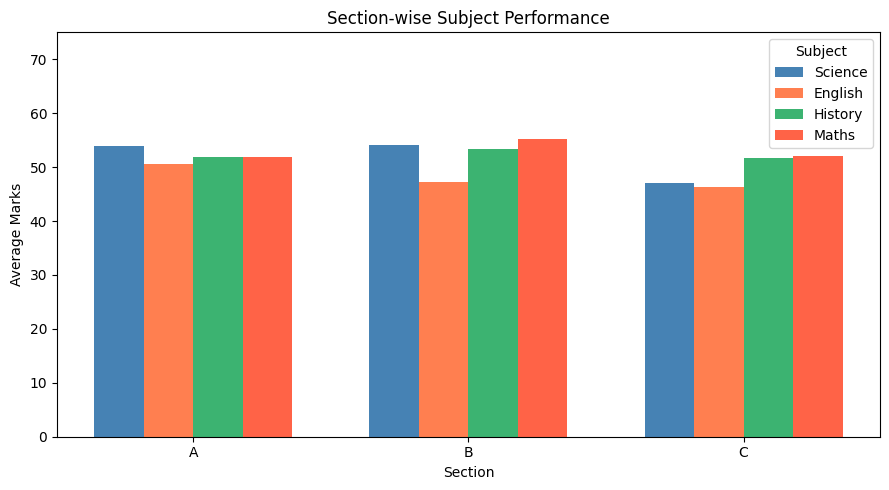

In [49]:
# section wise subject performance - grouped bar chart
sec_sub = df.groupby('Section')[subjects].mean().round(2)

x = np.arange(len(sec_sub.index))
w = 0.18
colors = ['steelblue', 'coral', 'mediumseagreen', 'tomato']

plt.figure(figsize=(9, 5))
for i, sub in enumerate(subjects):
    plt.bar(x + (i - 1.5) * w, sec_sub[sub], w, label=sub, color=colors[i])

plt.title('Section-wise Subject Performance')
plt.xlabel('Section')
plt.ylabel('Average Marks')
plt.xticks(x, sec_sub.index)
plt.legend(title='Subject')
plt.ylim(0, 75)
plt.tight_layout()
plt.savefig('chart4_section_subjects.png', dpi=120)
plt.show()

C:\Users\MUAWIYAH\AppData\Local\Temp\ipykernel_5084\914693938.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([male_pct, female_pct], labels=['Male', 'Female'], patch_artist=True)


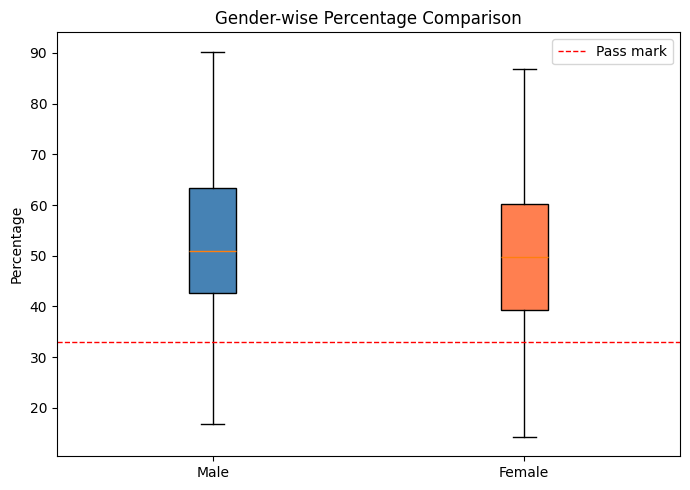

In [50]:
# boxplot to compare male and female percentage distribution
male_pct = df[df['Gender'] == 'Male']['Percentage']
female_pct = df[df['Gender'] == 'Female']['Percentage']

plt.figure(figsize=(7, 5))
bp = plt.boxplot([male_pct, female_pct], labels=['Male', 'Female'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')

plt.axhline(y=33, color='red', linestyle='--', linewidth=1, label='Pass mark')
plt.title('Gender-wise Percentage Comparison')
plt.ylabel('Percentage')
plt.legend()
plt.tight_layout()
plt.savefig('chart5_gender_box.png', dpi=120)
plt.show()

## Summary

In [51]:
topper = df.loc[df['Percentage'].idxmax()]
best_sec = df.groupby('Section')['Percentage'].mean().idxmax()

print('--- Summary ---')
print(f'Total students   : {len(df)}')
print(f'Passed           : {passed} ({passed/len(df)*100:.1f}%)')
print(f'Failed           : {failed} ({failed/len(df)*100:.1f}%)')
print(f'Class average    : {df["Percentage"].mean():.2f}%')
print(f'Topper           : {topper["Name"]} - {topper["Percentage"]}%')
print(f'Best section     : Section {best_sec}')
print()
print('Subject averages:')
for s in subjects:
    print(f'  {s}: {df[s].mean():.2f}')

--- Summary ---
Total students   : 250
Passed           : 62 (24.8%)
Failed           : 188 (75.2%)
Class average    : 51.18%
Topper           : Dunn - 90.25%
Best section     : Section B

Subject averages:
  Science: 51.44
  English: 47.98
  History: 52.27
  Maths: 53.02


## Saving the final data

In [52]:
# saving the updated dataframe with all new columns to a csv file
cols = ['id', 'Name', 'Gender', 'Age', 'Section',
        'Science', 'English', 'History', 'Maths',
        'Total', 'Percentage', 'Grade', 'Result', 'Best_Subject']

df[cols].to_csv('student_report_final.csv', index=False)
print('File saved: student_report_final.csv')
df[cols].head()

File saved: student_report_final.csv


,id,Name,Gender,Age,Section,Science,English,History,Maths,Total,Percentage,Grade,Result,Best_Subject
0,1,Bronnie,Female,13,C,21,81,62,49,213,53.25,C,FAIL,English
1,2,Lemmie,Male,15,B,29,41,17,40,127,31.75,F,FAIL,English
2,3,Danya,Female,14,C,12,87,16,96,211,52.75,C,FAIL,Maths
3,4,Denna,Female,14,B,15,53,82,33,183,45.75,C,FAIL,History
4,5,Jocelin,Male,14,A,43,6,3,21,73,18.25,F,FAIL,Science
